In [57]:
import numpy as np
import scanpy as sc
import anndata as ad
import pandas as pd
import scipy
from scipy.stats import pearsonr
import os
import torch
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from umap import UMAP
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import sys; sys.path += ['./../../']
from CardamomOT import NetworkModel as CardamomNetworkModel
from CardamomOT import train_classifier, predict_cell_types
from CardamomOT.inference.simulations import kon_ref, simulate_next_prot_ode
from harissa import NetworkModel as HarissaNetworkModel

In [58]:
SOFT_COLORS = [
    '#4878CF', '#E87B30', '#6DB36D', '#C94040', '#8C6DBF',
    '#57A8A8', '#C97BAA', '#8C7B6B', '#9CBF57', '#CF9B3A',
]
REF_COLOR = '#555555'   # grey  — reference data
SIM_COLOR = '#C94040'   # red   — CardamomOT model

In [59]:
def load_cardamom_data(cardamom_path):
    rna_traj = np.load(f'{cardamom_path}/data_rna.npy')[:, 1:]
    G = rna_traj.shape[1]
    model = CardamomNetworkModel(G)
    
    model.d = np.load(f'{cardamom_path}/degradations.npy')
    model.kon_simul = np.load(f'{cardamom_path}/data_kon_simul.npy')
    model.kon_beta = np.load(f'{cardamom_path}/data_kon_beta.npy')
    model.a = np.load(f'{cardamom_path}/mixture_parameters.npy')
    model.pi = np.load(f'{cardamom_path}/pi_zinb.npy')
    time = np.load(f'{cardamom_path}/data_times.npy')
    
    # Generate simulated data
    c = model.a[-1]
    ks_cells = np.max(model.a[:-1], axis=0)
    
    data_sim = np.random.negative_binomial(
        (ks_cells * model.kon_simul)[:, 1:].T,
        (c / (c + 1))[1:].reshape(G, 1),
    )
    zero_mask = (np.random.uniform(0, 1, data_sim.shape) < model.pi.reshape((G, 1)))
    print("new zeros ratio sim: ", np.sum(zero_mask == 1) / np.size(data_sim[1:, :]))
    data_sim = np.where(zero_mask, 0, data_sim).T

    data_beta = np.random.negative_binomial(
        (ks_cells * model.kon_beta)[:, 1:].T,
        (c / (c + 1))[1:].reshape(G, 1),
    )
    zero_mask = (np.random.uniform(0, 1, data_beta.shape) < model.pi.reshape((G, 1)))
    print("new zeros ratio beta: ", np.sum(zero_mask == 1) / np.size(data_beta[1:, :]))
    data_beta = np.where(zero_mask, 0, data_beta).T

    adata = sc.read(f'{cardamom_path}/../Data/data_full.h5ad')
    gene_names = adata.var_names.tolist()

    return rna_traj, data_sim, data_beta, time, gene_names

In [60]:
def plot_gene_correlation_heatmap(gene_array, gene_names=None, figsize=(10, 8), cmap='coolwarm'):
    """
    Calculate and plot correlation heatmap between all pairs of genes.
    
    Parameters:
    -----------
    gene_array : ndarray
        Array of shape (n_genes, n_samples) or (n_samples, n_genes)
    gene_names : list, optional
        Names of genes for axis labels
    figsize : tuple
        Figure size (width, height)
    cmap : str
        Colormap for heatmap
    """
    # Ensure genes are rows
    if gene_array.shape[0] > gene_array.shape[1]:
        gene_array = gene_array.T
    
    # Calculate correlation matrix
    corr_matrix = np.corrcoef(gene_array)
    print("Correlation matrix shape:", corr_matrix.shape)
    
    # Create heatmap
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(corr_matrix, cmap=cmap, 
                xticklabels=gene_names, yticklabels=gene_names,
                cbar_kws={'label': 'Correlation'}, ax=ax)
    
    plt.title('Gene-to-Gene Correlation Heatmap')
    plt.tight_layout()
    
    return fig, corr_matrix

In [61]:
def plot_correlation_scatter(
    gene_array1,
    gene_array2,
    gene_names=None,
    figsize=(8, 8),
    alpha=0.6,
    s=30,
    cmap='viridis',
    ax=None,
    show_colorbar=True,
    title=None,
    xlabel='Dataset 1 Correlation',
    ylabel='Dataset 2 Correlation',
):
    # Ensure genes are rows and compute correlations
    if gene_array1.shape[0] > gene_array1.shape[1]:
        gene_array1 = gene_array1.T
    if gene_array2.shape[0] > gene_array2.shape[1]:
        gene_array2 = gene_array2.T

    corr1 = np.corrcoef(gene_array1.astype(np.float32))
    corr2 = np.corrcoef(gene_array2.astype(np.float32))

    n_genes = corr1.shape[0]

    # Extract upper triangle correlations (all pairs, excluding diagonal)
    mask = np.triu(np.ones_like(corr1, dtype=bool), k=1)
    corr1_values = corr1[mask]
    corr2_values = corr2[mask]

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        created_fig = True
    else:
        fig = ax.figure

    scatter = ax.scatter(
        corr1_values,
        corr2_values,
        alpha=alpha,
        s=s,
        c=np.abs(corr1_values - corr2_values),
        cmap=cmap,
        edgecolors='black',
        linewidth=0.5,
    )

    # Add diagonal reference line
    lim = [
        min(corr1_values.min(), corr2_values.min()),
        max(corr1_values.max(), corr2_values.max()),
    ]
    ax.plot(lim, lim, 'k--', alpha=0.3, linewidth=1, label='Perfect agreement')

    # Calculate correlation of correlations
    corr_of_corrs = np.corrcoef(corr1_values, corr2_values)[0, 1]

    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    if title is None:
        title = f'Gene-Pair Correlation Comparison (R={corr_of_corrs:.3f})\n{n_genes} genes, {len(corr1_values)} pairs'
    ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    if show_colorbar:
        cbar = fig.colorbar(scatter, ax=ax)
        cbar.set_label('|Δ correlation|', fontsize=9)

    if created_fig:
        plt.tight_layout()

    return fig, corr_of_corrs, (corr1_values, corr2_values)

In [62]:
def plot_corr_of_corr_matrix(
    rna_traj,
    data_beta,
    data_sim,
    figsize=(6, 5),
    cmap='vlag',
    contrast_quantiles=(5, 95),
    dataset_name='CardamomOT Simulation',
    ax=None,
    annot=True,
    show_colorbar=True,
    title=None,
    jitter_eps=1e-8,
    random_state=0,
):

    rng = np.random.default_rng(random_state)

    def _to_gene_by_cell(arr):
        arr = np.asarray(arr)
        if arr.ndim != 2:
            raise ValueError(f'Expected a 2D array, got shape {arr.shape}.')
        # Heuristic: in these datasets, genes are usually fewer than cells.
        if arr.shape[0] > arr.shape[1]:
            arr = arr.T
        return arr.astype(np.float32, copy=False)

    def _pairwise_corr_vector(arr):
        # Add tiny noise only to constant genes so correlation is well-defined.
        std = np.nanstd(arr, axis=1)
        constant_mask = np.isclose(std, 0.0)
        if np.any(constant_mask):
            noise = rng.normal(loc=0.0, scale=jitter_eps, size=(constant_mask.sum(), arr.shape[1]))
            arr = arr.copy()
            arr[constant_mask] = arr[constant_mask] + noise.astype(arr.dtype, copy=False)

        corr = np.corrcoef(arr)
        # Keep only unique gene pairs (upper triangle, without diagonal).
        idx = np.triu_indices(corr.shape[0], k=1)
        vec = corr[idx]
        # Remove NaN/Inf values that can appear for constant genes.
        vec = vec[np.isfinite(vec)]
        if vec.size == 0:
            raise ValueError('No valid gene-pair correlations found after filtering NaN/Inf values.')
        return vec

    ref = _to_gene_by_cell(rna_traj)
    beta = _to_gene_by_cell(data_beta)
    sim = _to_gene_by_cell(data_sim)

    if not (ref.shape[0] == beta.shape[0] == sim.shape[0]):
        raise ValueError(
            'All inputs must have the same number of genes after orientation. '
            f'Got Reference={ref.shape[0]}, Beta={beta.shape[0]}, Sim={sim.shape[0]}.'
        )

    labels = ['Reference', 'Beta', 'Sim']
    vectors = {
        'Reference': _pairwise_corr_vector(ref),
        'Beta': _pairwise_corr_vector(beta),
        'Sim': _pairwise_corr_vector(sim),
    }

    corr_of_corr = np.eye(3, dtype=np.float32)
    for i, li in enumerate(labels):
        for j, lj in enumerate(labels):
            if i < j:
                m = min(vectors[li].size, vectors[lj].size)
                corr_ij = np.corrcoef(vectors[li][:m], vectors[lj][:m])[0, 1]
                corr_of_corr[i, j] = corr_ij
                corr_of_corr[j, i] = corr_ij

    # Adaptive color limits based on off-diagonal values to increase visual contrast.
    off_diag = corr_of_corr[np.triu_indices_from(corr_of_corr, k=1)]
    low_q, high_q = contrast_quantiles
    vmin, vmax = np.nanpercentile(off_diag, [low_q, high_q])

    if not (np.isfinite(vmin) and np.isfinite(vmax)):
        vmin, vmax = -1.0, 1.0
    elif np.isclose(vmin, vmax):
        span = max(abs(vmin), abs(vmax), 0.05)
        vmin, vmax = -span, span
    else:
        pad = 0.05 * (vmax - vmin)
        vmin -= pad
        vmax += pad

    vmin = max(-1.0, float(vmin))
    vmax = min(1.0, float(vmax))
    center = 0 if (vmin < 0 < vmax) else None

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        created_fig = True
    else:
        fig = ax.figure

    sns.heatmap(
        corr_of_corr,
        vmin=0,
        vmax=1,
        center=center,
        cmap=cmap,
        annot=annot,
        fmt='.2f',
        xticklabels=labels,
        yticklabels=labels,
        cbar=show_colorbar,
        cbar_kws={'label': 'Correlation of correlations'} if show_colorbar else None,
        square=True,
        ax=ax,
    )
    if title is None:
        title = f'{dataset_name} - Dataset to dataset correlation of gene pairs correlations'
    ax.set_title(title, fontsize=10)

    if created_fig:
        plt.tight_layout()

    return fig, corr_of_corr, vectors

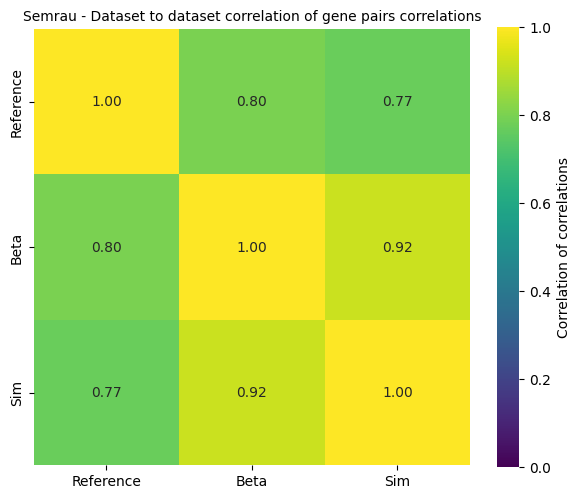

In [63]:
fig, corr3, vecs = plot_corr_of_corr_matrix(rna_traj_semrau, data_beta_semrau,
data_sim_semrau, cmap='viridis', dataset_name="Semrau"
)

In [64]:
cardamom_path = '../../../../data/Datas_exp/Semrau/cardamom'
rna_traj_semrau, data_sim_semrau, data_beta_semrau, time_semrau, gene_names_semrau = load_cardamom_data(cardamom_path)

# Kameneva data are stored in this folder in the current workspace setup.
cardamom_path = '../../../../data/Datas_exp/Data_Olivier/cardamom'
rna_traj_kameneva, data_sim_kameneva, data_beta_kameneva, time_kameneva, gene_names_kameneva = load_cardamom_data(cardamom_path)

cardamom_path = '../../../../data/Datas_exp/Schiebinger/cardamom'
rna_traj_schiebinger, data_sim_schiebinger, data_beta_schiebinger, time_schiebinger, gene_names_schiebinger = load_cardamom_data(cardamom_path)

new zeros ratio sim:  0.0
new zeros ratio beta:  0.0
new zeros ratio sim:  0.0
new zeros ratio beta:  0.0
new zeros ratio sim:  0.0
new zeros ratio beta:  0.0


Correlation matrix shape: (41, 41)


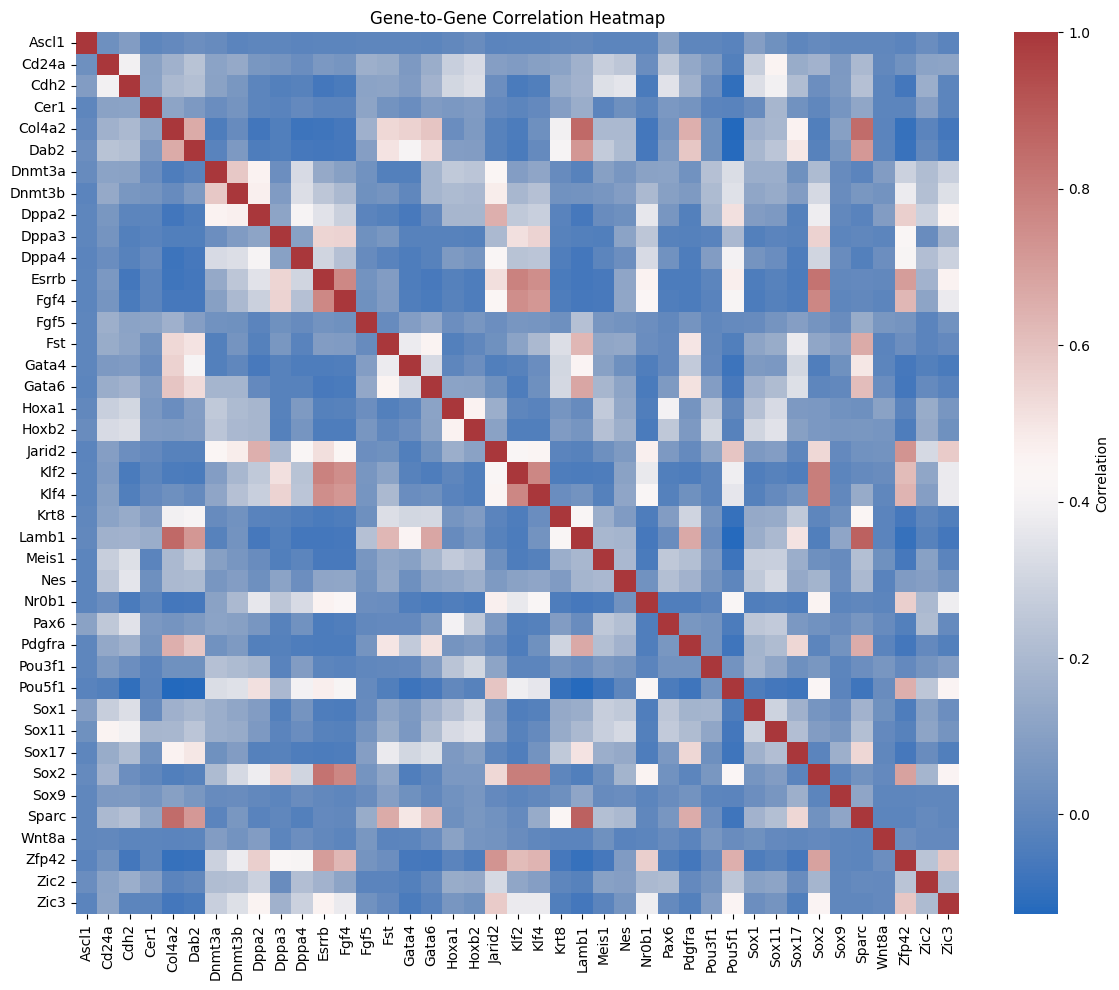

In [65]:
fig, corr = plot_gene_correlation_heatmap(rna_traj_semrau.T, gene_names=gene_names_semrau, figsize=(12, 10), cmap='vlag')

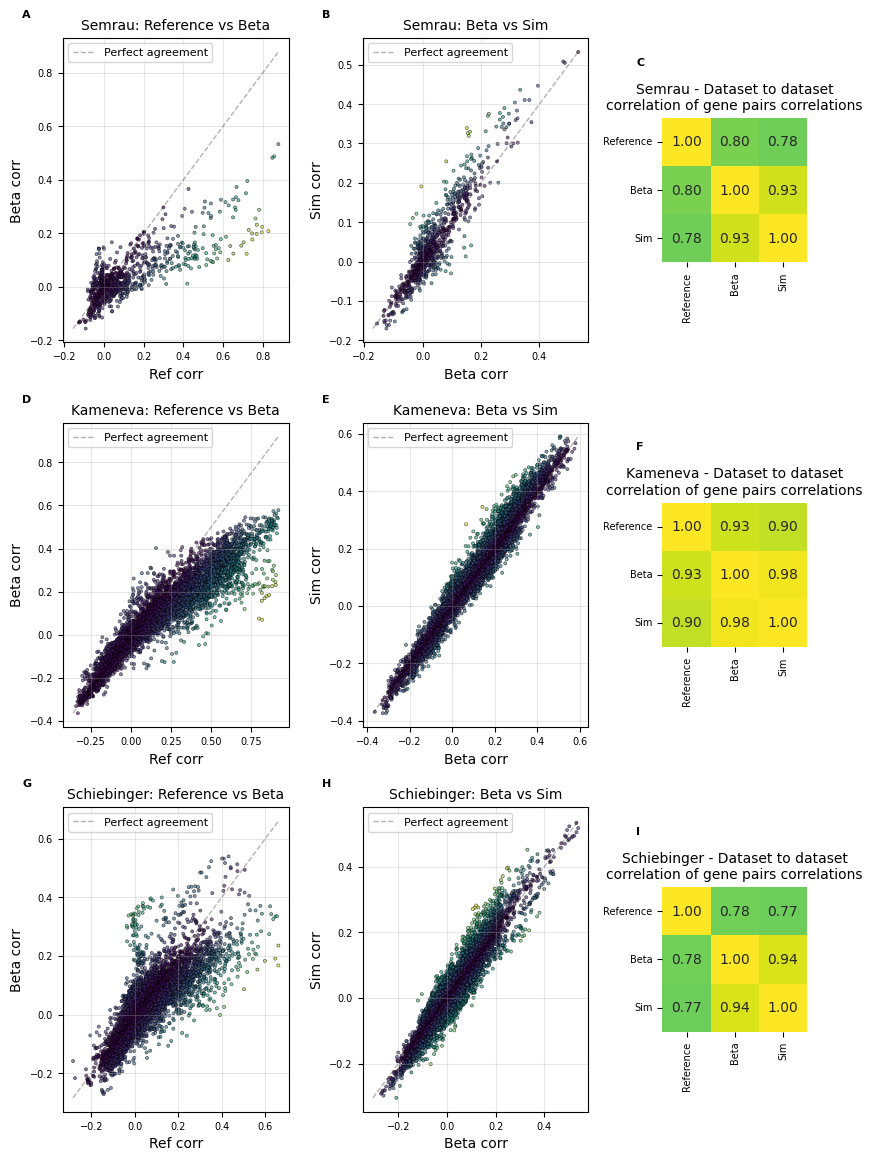

In [76]:
fig, axes = plt.subplots(
    3, 3,
    figsize=(8.27, 11.69),
    gridspec_kw={'width_ratios': [1.25, 1.25, 0.8]},
)

datasets = [
    ('Semrau', rna_traj_semrau, data_beta_semrau, data_sim_semrau),
    ('Kameneva', rna_traj_kameneva, data_beta_kameneva, data_sim_kameneva),
    ('Schiebinger', rna_traj_schiebinger, data_beta_schiebinger, data_sim_schiebinger),
]

for row, (name, rna_traj, data_beta, data_sim) in enumerate(datasets):
    # Left: rna_traj vs beta
    plot_correlation_scatter(
        rna_traj.T,
        data_beta.T,
        ax=axes[row, 0],
        alpha=0.6,
        s=5,
        cmap='viridis',
        show_colorbar=False,
        title=f'{name}: Reference vs Beta',
        xlabel='Ref corr',
        ylabel='Beta corr',
    )

    # Middle: beta vs sim
    plot_correlation_scatter(
        data_beta.T,
        data_sim.T,
        ax=axes[row, 1],
        alpha=0.6,
        s=5,
        cmap='viridis',
        show_colorbar=False,
        title=f'{name}: Beta vs Sim',
        xlabel='Beta corr',
        ylabel='Sim corr',
    )

    # Right: correlation-of-correlations matrix
    plot_corr_of_corr_matrix(
        rna_traj,
        data_beta,
        data_sim,
        ax=axes[row, 2],
        cmap='viridis',
        show_colorbar=False,
        title=f'{name} - Dataset to dataset\ncorrelation of gene pairs correlations',
    )

# Reduce tick label size across all subplots.
for ax in axes.flat:
    ax.tick_params(axis='both', which='major', labelsize=7)

# Shared labels for panel IDs (A-I). Raise C/F/I above matrix titles.
for i, (ax, label) in enumerate(zip(axes.flat, 'ABCDEFGHI')):
    y_pos = 1.35 if (i % 3 == 2) else 1.06
    ax.text(
        -0.18,
        y_pos,
        label,
        transform=ax.transAxes,
        ha='left',
        va='bottom',
        fontsize=8,
        fontweight='bold',
        clip_on=False,
    )

plt.tight_layout()
plt.savefig('figureS5.pdf', dpi=300, bbox_inches='tight')
plt.show()